# TikTok Video Claim vs. Opinion Classification

**Machine Learning Project | Random Forest and XGBoost**

### Objective
Build a binary classification model that predicts whether a TikTok video is classified as a **claim** or an **opinion**. The goal is to support the prioritization of videos for human review while keeping human moderation in the decision process.

## 1. Imports and Data Loading

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBClassifier

os.makedirs('images', exist_ok=True)
data = pd.read_csv('tiktok_dataset.csv')
data.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


## 2. Data Overview and Cleaning

The original dataset contains 19,382 rows and 12 columns. After removing rows with missing values, 19,084 observations remain. The target variable is `claim_status`.

In [2]:
print('Shape before cleaning:', data.shape)
print('\nMissing values:')
print(data.isna().sum())

# Remove rows with missing values.
data = data.dropna().copy()

print('\nShape after cleaning:', data.shape)
print('Duplicate rows:', data.duplicated().sum())


Shape before cleaning: (19382, 12)

Missing values:
#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

Shape after cleaning: (19084, 12)
Duplicate rows: 0


In [3]:
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19084.000000,1.908400e+04,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9542.500000,5.624840e+09,32.423811,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5509.220604,2.537030e+09,16.226470,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4771.750000,3.425100e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9542.500000,5.609500e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14313.250000,7.840823e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19084.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


### Outlier review

The engagement variables contain high-value observations. These were reviewed using the IQR rule rather than automatically removed because high engagement can represent legitimate TikTok videos and is potentially informative for classification.

In [4]:
count_cols = ['video_view_count', 'video_like_count', 'video_share_count', 'video_download_count', 'video_comment_count']

for col in count_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f'{col}: {len(outliers)} IQR outliers')

video_view_count: 0 IQR outliers
video_like_count: 1726 IQR outliers
video_share_count: 2508 IQR outliers
video_download_count: 2450 IQR outliers
video_comment_count: 2789 IQR outliers


In [5]:
## 3. Exploratory Analysis


In [6]:
# Create a text-length feature from the video transcription.
data['text_length'] = data['video_transcription_text'].str.len()

print(data.groupby('claim_status')['text_length'].mean())


claim_status
claim      95.376978
opinion    82.722562
Name: text_length, dtype: float64


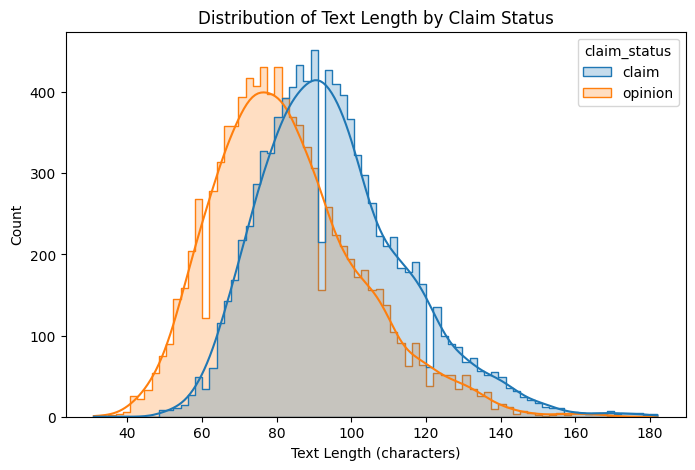

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='text_length', hue='claim_status', kde=True, element='step')
plt.title('Distribution of Text Length by Claim Status')
plt.xlabel('Text Length (characters)')
plt.ylabel('Count')
plt.savefig('text_length_distribution.png', bbox_inches='tight', dpi=300)
plt.show()


## 4. Feature Engineering and Preparation

The target `claim_status` is encoded as 1 for `claim` and 0 for `opinion`. The row number, `video_id`, and raw transcription text are excluded from the model. The transcription is represented by the engineered `text_length` feature. Categorical variables are one-hot encoded.


In [8]:
X = data.copy()

X = X.drop(['#', 'video_id', 'video_transcription_text'], axis=1)
X['claim_status'] = X['claim_status'].map({'opinion': 0, 'claim': 1})
X = pd.get_dummies(
    X,
    columns=['verified_status', 'author_ban_status'],
    drop_first=True
)

y = X.pop('claim_status')

print('Features:', list(X.columns))
print('Target distribution:')
print(y.value_counts())

Features: ['video_duration_sec', 'video_view_count', 'video_like_count', 'video_share_count', 'video_download_count', 'video_comment_count', 'text_length', 'verified_status_verified', 'author_ban_status_banned', 'author_ban_status_under review']
Target distribution:
claim_status
1    9608
0    9476
Name: count, dtype: int64


## 5. Train / Validation / Test Split

The data is divided into 60% training, 20% validation, and 20% test sets. The validation set is used for model selection, while the test set is reserved for final evaluation.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0, stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=0, stratify=y_train
)

print('Training:', X_tr.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Training: (11450, 10)
Validation: (3817, 10)
Test: (3817, 10)


## 6. Model A — Random Forest with Engagement Features

This model includes post-publication engagement variables such as views, likes, shares, downloads, and comments. These features can be highly predictive but may not be available immediately after upload, so this model is treated as a performance benchmark rather than a realistic early-classification deployment model.

Random Forest is tuned with 5-fold cross-validation. Recall is used as the refit metric because missing a claim can reduce the effectiveness of a review-prioritization workflow.


In [10]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'max_depth': [5, 7, None],
    'max_features': [0.3, 0.6],
    'max_samples': [0.7],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 3],
    'n_estimators': [75, 100, 200]
}

scoring = ['accuracy', 'precision', 'recall', 'f1']

rf_cv = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    scoring=scoring,
    refit='recall',
    cv=5,
    n_jobs=-1
)

rf_cv.fit(X_tr, y_tr)
print('Best CV recall:', rf_cv.best_score_)
print('Best parameters:', rf_cv.best_params_)

Best CV recall: 0.9899379336513443
Best parameters: {'max_depth': None, 'max_features': 0.6, 'max_samples': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 200}


In [11]:
rf_results = pd.DataFrame(rf_cv.cv_results_)
print('Best CV precision:', rf_results.loc[rf_cv.best_index_, 'mean_test_precision'])

Best CV precision: 1.0


In [12]:

# Check feature importances of the best estimator
best_rf = rf_cv.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)

# Display top features
print(importances.sort_values(ascending=False).head(10))

video_view_count                  0.605501
video_like_count                  0.246034
video_share_count                 0.069474
video_download_count              0.060494
video_comment_count               0.014333
text_length                       0.001911
video_duration_sec                0.001742
author_ban_status_banned          0.000359
author_ban_status_under review    0.000129
verified_status_verified          0.000022
dtype: float64


## 7. Model B — Early Classification

**Why Model B?**
Model A includes post-publication engagement metrics (`views`, `likes`, `shares`, `downloads`, and `comments`). These features can introduce target leakage for an early moderation workflow because engagement accumulates after publication.

**Objective:**
Model B removes post-publication engagement features and uses only information available at upload: `video_duration_sec`, `text_length`, `author_ban_status`, and `verified_status`. This provides a more realistic benchmark for early classification.


In [13]:
# List of engagement features to remove for early classification
engagement_cols = [
    'video_view_count',
    'video_like_count',
    'video_share_count',
    'video_download_count',
    'video_comment_count'
]

# Create X_model_b by dropping post-publication features
X_model_b = X.drop(columns=engagement_cols)

# Verify remaining features
print("Model B features:", X_model_b.columns.tolist())

Model B features: ['video_duration_sec', 'text_length', 'verified_status_verified', 'author_ban_status_banned', 'author_ban_status_under review']


In [14]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_model_b,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Model B training:', X_train_b.shape)
print('Model B test:', X_test_b.shape)


Model B training: (15267, 5)
Model B test: (3817, 5)


In [15]:
# Define and tune Model B.
rf_b = RandomForestClassifier(random_state=42)

cv_params = {
    'max_depth': [5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [50, 100, 200]
}

scoring = ['accuracy', 'precision', 'recall', 'f1']

rf_cv_b = GridSearchCV(
    estimator=rf_b,
    param_grid=cv_params,
    scoring=scoring,
    refit='precision',
    cv=5,
    n_jobs=-1
)

rf_cv_b.fit(X_train_b, y_train_b)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 7, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None chang

In [16]:
# Convert CV results to DataFrame
rf_results_b = pd.DataFrame(rf_cv_b.cv_results_)

# Print best CV precision score
best_precision_b = rf_results_b.loc[rf_cv_b.best_index_, 'mean_test_precision']
print(f"Model B - Best CV Precision: {best_precision_b:.4f}")

# Print best hyperparameters
print("Model B - Best Parameters:", rf_cv_b.best_params_)

Model B - Best CV Precision: 0.6827
Model B - Best Parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}


=== Model B Holdout Test Results ===
              precision    recall  f1-score   support

     opinion       0.68      0.65      0.66      1895
       claim       0.67      0.69      0.68      1922

    accuracy                           0.67      3817
   macro avg       0.67      0.67      0.67      3817
weighted avg       0.67      0.67      0.67      3817



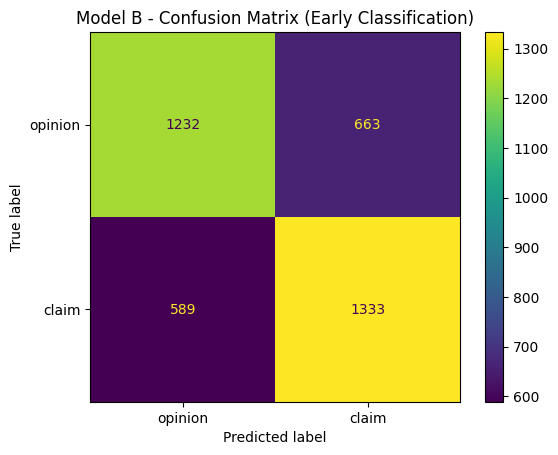

In [17]:
# Evaluate Model B on its independent holdout test set.
y_pred_b = rf_cv_b.best_estimator_.predict(X_test_b)

print('=== Model B Holdout Test Results ===')
print(classification_report(y_test_b, y_pred_b, target_names=['opinion', 'claim']))

cm = confusion_matrix(y_test_b, y_pred_b, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['opinion', 'claim'])
disp.plot(values_format='d')
plt.title('Model B - Confusion Matrix (Early Classification)')
plt.savefig('images/model_b_confusion_matrix.png', bbox_inches='tight')
plt.show()


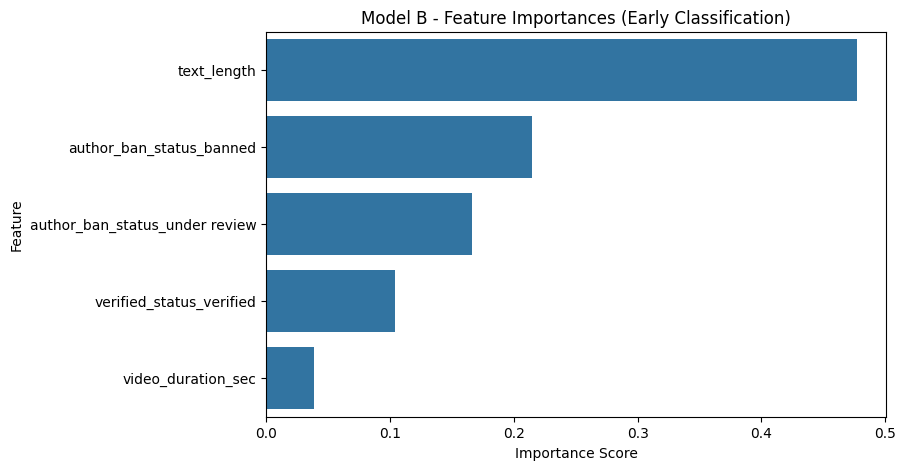

In [18]:
# Extract and visualize Model B feature importances.
importances_b = pd.Series(
    rf_cv_b.best_estimator_.feature_importances_,
    index=X_model_b.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances_b.values, y=importances_b.index)
plt.title('Model B - Feature Importances (Early Classification)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.savefig('images/model_b_feature_importances.png', bbox_inches='tight')
plt.show()


## 8. XGBoost Model


In [19]:
xgb = XGBClassifier(objective='binary:logistic', random_state=0, eval_metric='logloss')

xgb_params = {
    'max_depth': [4, 8, 12],
    'min_child_weight': [3, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [300, 500]
}

xgb_cv = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    scoring=scoring,
    refit='recall',
    cv=5,
    n_jobs=-1
)

xgb_cv.fit(X_tr, y_tr)
print('Best CV recall:', xgb_cv.best_score_)
print('Best parameters:', xgb_cv.best_params_)

Best CV recall: 0.9887235593138671
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 300}


In [20]:
xgb_results = pd.DataFrame(xgb_cv.cv_results_)
print('Best CV precision:', xgb_results.loc[xgb_cv.best_index_, 'mean_test_precision'])

Best CV precision: 0.997897955821978


In [21]:
# Compare validation performance for the two tuned models.
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'CV Recall': [rf_cv.best_score_, xgb_cv.best_score_],
    'CV Precision': [
        rf_results.loc[rf_cv.best_index_, 'mean_test_precision'],
        xgb_results.loc[xgb_cv.best_index_, 'mean_test_precision']
    ]
})

comparison


,Model,CV Recall,CV Precision
0,Random Forest,0.989938,1.000000
1,XGBoost,0.988724,0.997898


## 9. Validation Set Evaluation


In [22]:
def evaluate_model(name, model, X_eval, y_eval):
    preds = model.predict(X_eval)
    print(f'### {name}')
    print(classification_report(y_eval, preds, target_names=['opinion', 'claim']))
    return preds

rf_val_preds = evaluate_model('Random Forest', rf_cv.best_estimator_, X_val, y_val)
xgb_val_preds = evaluate_model('XGBoost', xgb_cv.best_estimator_, X_val, y_val)

### Random Forest
              precision    recall  f1-score   support

     opinion       0.99      1.00      1.00      1895
       claim       1.00      0.99      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817

### XGBoost
              precision    recall  f1-score   support

     opinion       0.99      1.00      1.00      1895
       claim       1.00      0.99      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



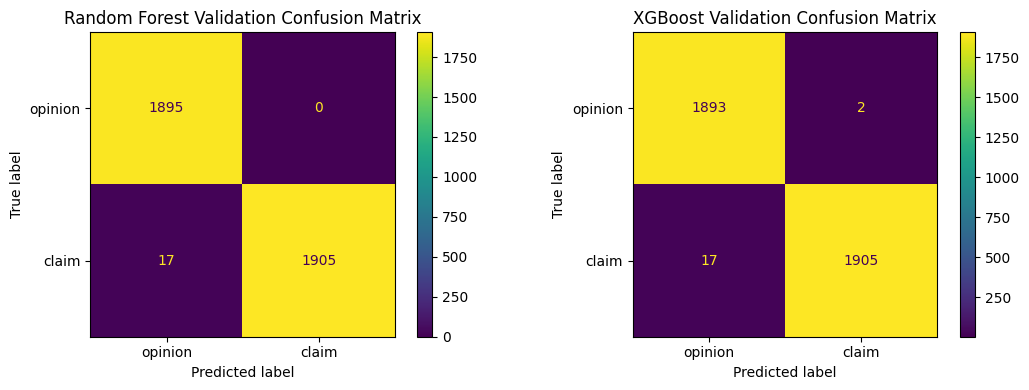

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, name, model in [
    (axes[0], 'Random Forest', rf_cv.best_estimator_),
    (axes[1], 'XGBoost', xgb_cv.best_estimator_)
]:
    preds = model.predict(X_val)
    cm = confusion_matrix(y_val, preds, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=['opinion', 'claim']).plot(ax=ax, values_format='d')
    ax.set_title(f'{name} Validation Confusion Matrix')

plt.tight_layout()
plt.savefig('validation_confusion_matrices.png', bbox_inches='tight', dpi=300)
plt.show()

## 10. Final Test Evaluation

The Random Forest model is retained as the champion model based on the cross-validation comparison above. The independent test set is evaluated only after model selection.


In [24]:
champion_model = rf_cv.best_estimator_
y_test_pred = champion_model.predict(X_test)

print(classification_report(y_test, y_test_pred, target_names=['opinion', 'claim']))
print('Accuracy:', accuracy_score(y_test, y_test_pred))
print('Precision:', precision_score(y_test, y_test_pred))
print('Recall:', recall_score(y_test, y_test_pred))
print('F1:', f1_score(y_test, y_test_pred))

              precision    recall  f1-score   support

     opinion       0.99      1.00      1.00      1895
       claim       1.00      0.99      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817

Accuracy: 0.9960702122085408
Precision: 1.0
Recall: 0.9921956295525495
F1: 0.9960825280752155


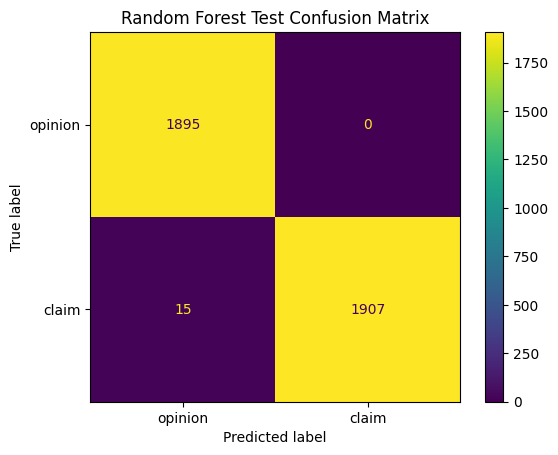

In [25]:
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=['opinion', 'claim']).plot(values_format='d')
plt.title('Random Forest Test Confusion Matrix')
plt.show()

## 11. Feature Importance


video_view_count                  0.605501
video_like_count                  0.246034
video_share_count                 0.069474
video_download_count              0.060494
video_comment_count               0.014333
text_length                       0.001911
video_duration_sec                0.001742
author_ban_status_banned          0.000359
author_ban_status_under review    0.000129
verified_status_verified          0.000022
dtype: float64


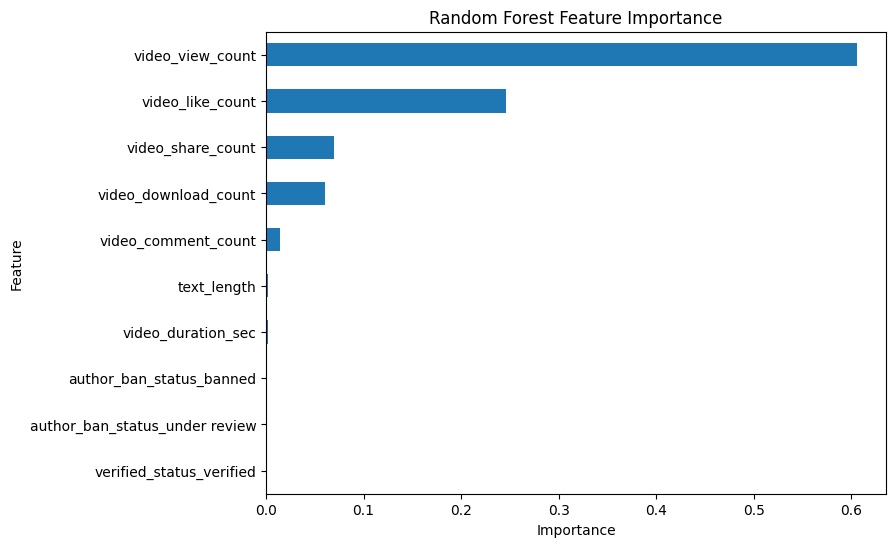

In [26]:
feature_importance = pd.Series(
    champion_model.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 6))
feature_importance.sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 12. Key Findings

- The dataset contains 19,084 complete observations after missing-value removal.
- The target classes are relatively balanced: 9,608 claim videos and 9,476 opinion videos.
- Model A achieves very high cross-validation performance, but its strongest predictors are post-publication engagement measures, limiting its suitability for immediate classification.
- Model B removes engagement features and provides a more realistic early-classification benchmark; its recorded holdout accuracy is approximately 67%.
- The final Random Forest test metrics are generated by the corrected final evaluation cells when the notebook is run from start to finish.

### Important limitation
The difference between Model A and Model B shows why feature availability matters. Very high performance from engagement-based features should not automatically be interpreted as real-time, pre-publication classification performance. Future evaluation should use newer data and confirm that the selected features are available at the intended prediction time.


## 13. Conclusion

The project demonstrates an end-to-end binary classification workflow using feature engineering, stratified train/validation/test splitting, cross-validation, hyperparameter tuning, Random Forest, and XGBoost. The engagement-based Random Forest and XGBoost models achieve very high cross-validation performance, while the early-classification Random Forest provides a more realistic benchmark when post-publication engagement is excluded.

For a real moderation workflow, model predictions should support—not replace—human review. Future work should test the models on newer data, examine performance across different content and creator groups, and evaluate whether the available features support the intended timing of prediction.
